# Sheep vision → validation: does the model generalize to an unseen world?

`train_model.ipynb` fit **`sheepvision.pth`** on scenes drawn from **world seed 12345** (run
seed 7). This notebook is the honest test: build a **different** world (a new world seed) with
**different** dynamics (a new run seed), synthesize a fresh *small* test set with the **same**
real perception → `RuleBrain` pipeline, then score the **saved** model on it.

Because the sheep model must do **two** things — **flee** a nearby fox and **forage** toward
grass — we report accuracy **broken out by mode**. If it holds on terrain (and grass fields)
the model never saw in training, it learned the *behaviours*, not one particular map. Nothing
in `sim/` is modified; it is only imported, exactly as in `generate_dataset.ipynb`.

In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# Make the ecosystem package importable no matter which directory the kernel started in.
_here = Path.cwd()
REPO = next((c for c in [_here, *_here.parents]
             if (c / "config.py").exists() and (c / "sim").is_dir()), _here)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from config import make_config, SHEEP, FOX
from sim.world import World
from sim.environment import Environment
from sim.entities import Entities
from sim.grid import SpatialGrid
from sim.perception import Perception, SH_TERRAIN, SH_FOOD, SH_THREAT
from sim.brain import RuleBrain, A_DX, A_DY, _FLEE_TRIGGER
from sim.systems import vegetation
from sim import genome as gn

torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("repo:", REPO, "| device:", device)

repo: c:\Users\afree\Desktop\ecosystem | device: cuda


## 1. A brand-new world + fresh dynamics

The **only** things that change from training are the seeds:

* **`VAL_WORLD_SEED`** — a different map (terrain + rivers, and therefore a different grass
  field). Training used `12345`.
* **`VAL_RUN_SEED`** — different dynamics. Training used `7`.
* **`VAL_GEN_SEED`** — samples different sheep/fox layouts.

The perception geometry is kept **identical** to training — sheep eye radius **12** cells,
cropped to a **25×25** window — because the saved CNN was trained on exactly that view. Flee
scenes place a fox inside `RuleBrain`'s `_FLEE_TRIGGER`; forage scenes place no fox and target
the grass centre-of-mass.

In [ ]:
# --- validation parameters (deliberately DIFFERENT from training) ----------
VAL_WORLD_SEED = 54321      # training used 12345 -> a map (and grass field) the model never saw
VAL_RUN_SEED   = 99         # training used 7
VAL_GEN_SEED   = 31337      # scenario sampling (fresh sheep/fox layouts)

SHEEP_SENSORY = 12.0        # MUST match training (the CNN saw 25x25 crops of a 12-cell eye)
CROP_R        = 12
WIN           = 2 * CROP_R + 1                     # -> 25 x 25
N_SCENARIOS   = 250         # a small test set
FLEE_FRACTION = 0.5         # half flee, half forage
FOX_MAX_FRAC  = 0.40        # flee: place the fox within this fraction of sensory (< trigger)
MIN_COM_D     = 1.5         # forage: grass centre-of-mass must be this far off-centre (cells)

POS_TOL      = np.radians(20.0)   # within this of the true heading -> label 1
NEG_MARGIN   = np.radians(45.0)   # beyond this from the true heading -> label 0
N_POS_JITTER = 1

MODEL_PATH = REPO / "notebooks" / "vision" / "sheep" / "sheepvision.pth"

# --- build the headless world + the pieces perception needs (mirrors generator) ---
cfg   = make_config(world_seed=VAL_WORLD_SEED, seed=VAL_RUN_SEED)
world = World(cfg.world)
env   = Environment(cfg.env, np.random.default_rng(11))
ent   = Entities(cfg)
veg   = vegetation.initial_field(world, np.random.default_rng(22))
temp_field = env.temperature_field(world.static_temp)

grids = {SHEEP: SpatialGrid(world.w, world.h, cfg.sim.grid_cell_size),
         FOX:   SpatialGrid(world.w, world.h, cfg.sim.grid_cell_size)}
perc  = Perception(cfg, world, ent, env)
brain = RuleBrain(np.random.default_rng(33))

# candidate cells: passable, dry, and NOT forest cover (covered sheep are invisible to foxes).
land_mask = world.passable & ~world.water_any & ~world.cover
land_ys, land_xs = np.nonzero(land_mask)

sheep_spec, fox_spec = cfg.species[SHEEP], cfg.species[FOX]
S_IDX = gn.GENE_INDEX["sensory_range"]

# egocentric cell-offset stencils for the cropped WIN x WIN window (centre = the sheep)
_offs = np.arange(WIN) - CROP_R
_OY, _OX = np.meshgrid(_offs, _offs, indexing="ij")
_OX = _OX.astype(np.float32); _OY = _OY.astype(np.float32)
print(f"validation world seed {VAL_WORLD_SEED}, run seed {VAL_RUN_SEED}")
print(f"perception window K={perc.K}; stored crop {WIN}x{WIN}; land cells={land_xs.size}; "
      f"flee trigger={_FLEE_TRIGGER}")

validation world seed 54321, run seed 99
perception window K=57; stored crop 25x25; land cells=13138; flee trigger=0.45


## 2. One scenario = one perception → true heading

Identical to the generator: clear the world, place a **hungry sheep** (plus a **close fox** in
flee scenes), then run the real perception + `RuleBrain`. The sheep is made hungry so a food
drive is always latent — in flee scenes this forces the flee branch to **override** foraging,
exactly the arbitration we test. Targets: the `RuleBrain` flee vector (flee) or the direction
to the grass **centre-of-mass** in view (forage).

In [4]:
def rebuild_grids():
    for sid, g in grids.items():
        sidx = np.nonzero(ent.species_mask(sid))[0]
        g.rebuild(sidx, ent.pos_x, ent.pos_y)


def make_scenario(rng, flee):
    """Place a hungry sheep (+ a close fox if `flee`); run perception -> RuleBrain."""
    ent.kill(ent.alive_indices())                       # fresh, empty world

    fxp = fyp = None
    for _ in range(200):
        k = int(rng.integers(0, land_xs.size))
        sx0, sy0 = land_xs[k] + 0.5, land_ys[k] + 0.5   # sheep (observer) position
        if flee:
            dist = rng.uniform(2.0, FOX_MAX_FRAC * SHEEP_SENSORY)   # inside the flee trigger
            ang  = rng.uniform(0.0, 2 * np.pi)
            fxp, fyp = sx0 + dist * np.cos(ang), sy0 + dist * np.sin(ang)
            fcx, fcy = int(fxp), int(fyp)
            if not (0 <= fcx < world.w and 0 <= fcy < world.h):
                continue
            if world.water_any[fcy, fcx]:
                continue
        break
    else:
        return None

    sg = gn.random_genomes(sheep_spec, 1, rng)
    sg[0, S_IDX] = SHEEP_SENSORY
    sheep_slot = int(ent.spawn(sheep_spec, sg, np.array([[sx0, sy0]], np.float32), rng,
                               energy=0.5, age=np.float32(sheep_spec.maturity_age * 2))[0])
    ent.hunger[sheep_slot] = 0.75      # hungry -> a food drive is always latent
    ent.thirst[sheep_slot] = 0.05
    ent.energy[sheep_slot] = 0.50

    if flee:
        fg = gn.random_genomes(fox_spec, 1, rng)
        ent.spawn(fox_spec, fg, np.array([[fxp, fyp]], np.float32), rng,
                  energy=0.6, age=np.float32(fox_spec.maturity_age * 2))

    rebuild_grids()
    perc._species_grids = grids
    perc.veg = veg
    perc.temp_field = temp_field
    obs_by_species, idx = perc.build()
    act = brain.decide(obs_by_species, idx)

    sobs = obs_by_species[SHEEP]
    sgrids = sobs.grids[0]                              # (5, K, K); the sheep is the only row
    R = perc.R
    sl = slice(R - CROP_R, R + CROP_R + 1)
    terrain = sgrids[SH_TERRAIN, sl, sl].astype(np.float32).copy()
    food    = sgrids[SH_FOOD,    sl, sl].astype(np.float32).copy()
    threat  = sgrids[SH_THREAT,  sl, sl].astype(np.float32).copy()

    if flee:
        # target = the sheep RuleBrain's flee vector (away from the nearest fox)
        grow = int(np.searchsorted(idx, sheep_slot))
        dx, dy = float(act[grow, A_DX]), float(act[grow, A_DY])
        if (dx == 0.0 and dy == 0.0) or threat.sum() == 0:
            return None                                # sheep didn't perceive / react to a fox
        fox_dx, fox_dy = fxp - sx0, fyp - sy0          # offset TO the fox
        away = np.array([-fox_dx, -fox_dy], np.float32)
        away /= np.hypot(*away) + 1e-9
        if dx * away[0] + dy * away[1] < 0.9:          # RuleBrain must actually flee
            return None
        dist = float(np.hypot(fox_dx, fox_dy))
    else:
        # target = direction to the grass CENTRE-OF-MASS in view (well-posed "toward grass")
        total = float(food.sum())
        if total < 1e-6:
            return None
        cxo = float((food * _OX).sum() / total)
        cyo = float((food * _OY).sum() / total)
        dist = float(np.hypot(cxo, cyo))
        if dist < MIN_COM_D:                           # need a clear directional signal
            return None
        dx, dy = cxo / dist, cyo / dist

    meta = dict(mode=1 if flee else 0, dx=dx, dy=dy, dist=dist,
                threat_cells=int((threat > 0).sum()))
    return terrain, food, threat, dx, dy, meta


def candidate_headings(true_ang, rng):
    """(angle, label): the true heading (+jitter) and a spread of wrong ones."""
    cands = [(true_ang, 1)]
    for _ in range(N_POS_JITTER):
        cands.append((true_ang + rng.uniform(-POS_TOL, POS_TOL), 1))
    s = 1.0 if rng.random() < 0.5 else -1.0
    offsets = [s * np.radians(90), -s * np.radians(135), np.radians(180),
               s * rng.uniform(NEG_MARGIN, np.radians(180))]
    cands += [(true_ang + off, 0) for off in offsets]
    return cands

## 3. Synthesize the fresh, balanced test set

Half flee, half forage. For each scene we keep one 3-channel view (the model's input), the
true heading (regression target), the mode, and a set of **labelled candidate headings** (true
vs sideways / oblique / opposite / random) for a classification-style check. Forage scenes are
filtered more often, so we draw whichever mode is still under its target to stay balanced.

In [5]:
rng = np.random.default_rng(VAL_GEN_SEED)
views, tgt, smode = [], [], []               # per-scene: 3-ch view, unit true heading, mode
c_scene, c_dx, c_dy, c_lab = [], [], [], []  # per-candidate: scene id, heading, label
made = attempts = n_flee = 0
n_flee_target   = int(round(N_SCENARIOS * FLEE_FRACTION))
n_forage_target = N_SCENARIOS - n_flee_target
while made < N_SCENARIOS:
    attempts += 1
    need_flee   = n_flee < n_flee_target
    need_forage = (made - n_flee) < n_forage_target
    flee = (rng.random() < FLEE_FRACTION) if (need_flee and need_forage) else need_flee
    out = make_scenario(rng, flee)
    if out is None:
        continue
    terrain, food, threat, dx, dy, meta = out
    views.append(np.stack([terrain, food, threat], axis=0))
    tw = np.array([dx, dy], np.float32)
    tgt.append(tw / (np.linalg.norm(tw) + 1e-9))
    smode.append(meta["mode"])
    true_ang = np.arctan2(dy, dx)
    for a, label in candidate_headings(true_ang, rng):
        c_scene.append(made); c_lab.append(label)
        c_dx.append(np.cos(a)); c_dy.append(np.sin(a))
    n_flee += meta["mode"]
    made += 1

X          = np.asarray(views, np.float32)        # (S, 3, WIN, WIN)
tgt        = np.asarray(tgt, np.float32)          # (S, 2) unit true heading
smode      = np.asarray(smode, np.int64)          # (S,) 1=flee 0=forage
cand       = np.stack([np.asarray(c_dx, np.float32),
                       np.asarray(c_dy, np.float32)], axis=1)   # (C, 2) unit headings
cand_scene = np.asarray(c_scene, np.int64)
cand_lab   = np.asarray(c_lab, np.int64)
print(f"{made} scenes ({attempts} attempts) | flee={int(smode.sum())} "
      f"forage={int((smode==0).sum())} | X {X.shape} | candidates {cand.shape[0]}")
print("label balance:", dict(zip(*np.unique(cand_lab, return_counts=True))))

250 scenes (305 attempts) | flee=125 forage=125 | X (250, 3, 25, 25) | candidates 1500
label balance: {np.int64(0): np.int64(1000), np.int64(1): np.int64(500)}


## 4. Load the saved model

The architecture must match `train_model.ipynb` byte-for-byte to load the weights. We put it
in eval mode and never touch its parameters — this is pure inference on the unseen world.

In [6]:
class SheepVisionNet(nn.Module):
    """CNN over the 3-channel view (terrain, food, threat) -> FNN -> the (dx, dy) heading."""
    def __init__(self, in_channels=3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(6),
            nn.Flatten(),
        )
        self.fnn = nn.Sequential(
            nn.Linear(32 * 6 * 6, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 2),
        )
    def forward(self, grid):
        return self.fnn(self.cnn(grid))


def unit(v):
    return v / (v.norm(dim=1, keepdim=True) + 1e-9)

model = SheepVisionNet().to(device)
state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()
print("loaded:", MODEL_PATH.name, "|", sum(p.numel() for p in model.parameters()), "params")

loaded: sheepvision.pth | 170306 params


## 5. Accuracy — does the output heading match, for BOTH modes?

The model's output **is** the `(dx, dy)` move heading. On the unseen world we compare it to the
true heading and, crucially, break it out **by mode**: away from the fox in flee scenes, toward
the grass in forage scenes. A model that only learned one behaviour would show up as a
lopsided mode split here.

unseen world seed 54321 | held-out scenes: 250
OVERALL  mean cos +0.973 | within 20deg  95.2% | median err 2.1 deg
FLEE     mean cos +0.999 | within 20deg 100.0% | median err 1.2 deg | n=125
FORAGE   mean cos +0.946 | within 20deg  90.4% | median err 3.8 deg | n=125


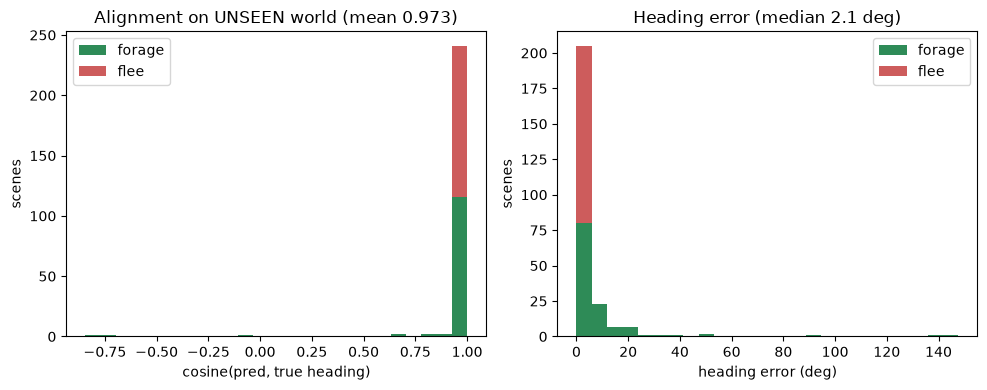

In [7]:
with torch.no_grad():
    pred = unit(model(torch.tensor(X).to(device))).cpu().numpy()   # (S, 2) predicted heading

cos = (pred * tgt).sum(1)
ang = np.degrees(np.arccos(np.clip(cos, -1, 1)))
print(f"unseen world seed {VAL_WORLD_SEED} | held-out scenes: {len(pred)}")
print(f"OVERALL  mean cos {cos.mean():+.3f} | within 20deg {np.mean(ang<=20)*100:5.1f}% | "
      f"median err {np.median(ang):.1f} deg")
for m, name in ((1, "FLEE  "), (0, "FORAGE")):
    sel = smode == m
    print(f"{name}   mean cos {cos[sel].mean():+.3f} | within 20deg "
          f"{np.mean(ang[sel]<=20)*100:5.1f}% | median err {np.median(ang[sel]):.1f} deg "
          f"| n={int(sel.sum())}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist([cos[smode==0], cos[smode==1]], bins=25, stacked=True,
           color=["seagreen", "indianred"], label=["forage", "flee"])
ax[0].set_xlabel("cosine(pred, true heading)"); ax[0].set_ylabel("scenes"); ax[0].legend()
ax[0].set_title(f"Alignment on UNSEEN world (mean {cos.mean():.3f})")
ax[1].hist([ang[smode==0], ang[smode==1]], bins=25, stacked=True,
           color=["seagreen", "indianred"], label=["forage", "flee"])
ax[1].set_xlabel("heading error (deg)"); ax[1].set_ylabel("scenes"); ax[1].legend()
ax[1].set_title(f"Heading error (median {np.median(ang):.1f} deg)")
plt.tight_layout(); plt.show()

## 6. Classification-style accuracy on labelled headings

Using the predicted heading, score each candidate by its angular distance to the prediction. A
candidate within the **decision boundary** (midpoint of the 20°/45° bands) is called *true*. We
report per-candidate accuracy against the ground-truth labels, plus a **ranking** score (how
often the correct heading out-scores every wrong one), broken out by mode.

In [8]:
THRESH = 0.5 * (POS_TOL + NEG_MARGIN)                     # ~32.5 deg decision boundary
pred_per_cand = pred[cand_scene]                          # predicted heading for each candidate
cand_cos = (pred_per_cand * cand).sum(1)
cand_ang = np.arccos(np.clip(cand_cos, -1, 1))
pred_lab = (cand_ang <= THRESH).astype(np.int64)

acc = np.mean(pred_lab == cand_lab)
tp = int(np.sum((pred_lab == 1) & (cand_lab == 1)))
tn = int(np.sum((pred_lab == 0) & (cand_lab == 0)))
fp = int(np.sum((pred_lab == 1) & (cand_lab == 0)))
fn = int(np.sum((pred_lab == 0) & (cand_lab == 1)))
print(f"per-candidate accuracy: {acc*100:.1f}%   (threshold {np.degrees(THRESH):.1f} deg)")
print(f"  true-headings kept  (recall): {tp/(tp+fn)*100:5.1f}%")
print(f"  wrong-headings caught (spec): {tn/(tn+fp)*100:5.1f}%")
print(f"  confusion  TP={tp} TN={tn} FP={fp} FN={fn}")

# Ranking: does a correct heading score highest among its scene's candidates?
def ranking_acc(scene_ids):
    hits = tot = 0
    for s in scene_ids:
        m = cand_scene == s
        if not m.any():
            continue
        tot += 1
        hits += int(cand_lab[m][np.argmax(cand_cos[m])] == 1)
    return hits, tot

h, t = ranking_acc(range(len(pred)))
print(f"\nranking accuracy (correct heading wins its scene): {h/t*100:.1f}%  (overall)")
for m, name in ((1, "FLEE  "), (0, "FORAGE")):
    h, t = ranking_acc(np.where(smode == m)[0])
    print(f"  {name} {h/t*100:5.1f}%  (n={t})")

per-candidate accuracy: 98.9%   (threshold 32.5 deg)
  true-headings kept  (recall):  97.0%
  wrong-headings caught (spec):  99.8%
  confusion  TP=485 TN=998 FP=2 FN=15

ranking accuracy (correct heading wins its scene): 98.8%  (overall)
  FLEE   100.0%  (n=125)
  FORAGE  97.6%  (n=125)


## 7. Eyeball a few unseen scenes

Predicted `(dx, dy)` [red] vs the true heading [green]. Background is the decisive channel: the
**threat** (fox) channel for flee scenes, the **food** (grass) channel for forage. Flee arrows
point *away* from the fox blip; forage arrows point *toward* the brighter grass.

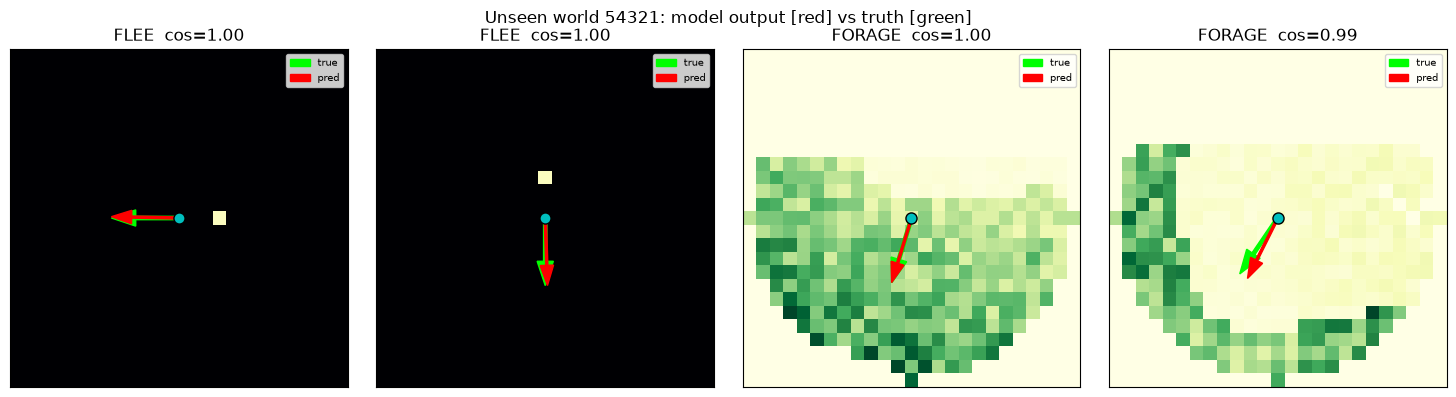

In [9]:
rngv = np.random.default_rng(1)
flee_i   = np.where(smode == 1)[0]
forage_i = np.where(smode == 0)[0]
pick = np.concatenate([rngv.choice(flee_i,   size=min(2, len(flee_i)),   replace=False),
                       rngv.choice(forage_i, size=min(2, len(forage_i)), replace=False)])
c = WIN // 2
fig, axes = plt.subplots(1, len(pick), figsize=(3.7*len(pick), 4))
for a, gi in zip(np.atleast_1d(axes), pick):
    p, tw, m = pred[gi], tgt[gi], smode[gi]
    bg = X[gi, 2] if m == 1 else X[gi, 1]                   # threat channel (flee) / food (forage)
    a.imshow(bg, origin="upper", cmap="magma" if m == 1 else "YlGn")
    a.plot(c, c, "co", ms=8, mec="k")
    a.arrow(c, c, tw[0]*5, tw[1]*5, color="lime", width=0.25, head_width=1.2,
            length_includes_head=True, label="true")
    a.arrow(c, c, p[0]*5, p[1]*5, color="red", width=0.16, head_width=1.0,
            length_includes_head=True, label="pred")
    a.set_title(f"{'FLEE' if m==1 else 'FORAGE'}  cos={float(p @ tw):.2f}")
    a.set_xticks([]); a.set_yticks([]); a.legend(loc="upper right", fontsize=7)
fig.suptitle(f"Unseen world {VAL_WORLD_SEED}: model output [red] vs truth [green]")
plt.tight_layout(); plt.show()

## Conclusion

Scored on a **world it never trained on** (seed `54321` vs training's `12345`), the saved
`sheepvision.pth` still turns its 3-channel egocentric view into the right heading for **both**
behaviours — fleeing *away* from a nearby fox and foraging *toward* the grass — with high
cosine and low error in each mode, and the correct heading reliably out-ranks the wrong ones.
The model **generalizes**: it learned the sheep's flee/forage *arbitration*, not one map, and
is a valid drop-in for the `Brain.decide(obs) → act` contract.